# Neural Networks

In [15]:
%pip install numpy tensorflow-macos matplotlib scikit-learn seaborn

Note: you may need to restart the kernel to use updated packages.


In [3]:
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Flatten, Input
from tensorflow.keras.losses import SparseCategoricalCrossentropy

# 1. Load the dataset (Handwritten digits 0-9)
mnist = tf.keras.datasets.mnist
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# 2. Normalize the data
# Pixel values are 0-255. We scale them to 0-1 to help the model learn faster.
X_train, X_test = X_train / 255.0, X_test / 255.0

# 3. Define the Architecture
model = Sequential([
    # This takes the 28x28 grid and "unrolls" it into a 784-number long list
    Input(shape=(28, 28)), 
    Flatten(), 
    
    # Hidden Layer 1: 128 neurons searching for basic shapes/edges
    Dense(128, activation='relu', name="Layer1"),
    
    # Hidden Layer 2: 64 neurons combining shapes into digit parts
    Dense(64, activation='relu', name="Layer2"),
    
    # Output Layer: 10 neurons (one for each digit 0-9)
    # We use NO activation here (Linear) to produce 'Logits'
    Dense(10, name="OutputLayer")
])

# 4. Compile the Model
model.compile(
    optimizer='adam',
    # 'from_logits=True' is used because our last layer has no activation
    loss=SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

# 5. Train the model
print("Starting training...")
model.fit(X_train, y_train, epochs=10)

# 6. Evaluate
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=2)
print(f'\nAccuracy on unseen digits: {test_acc*100:.2f}%')

Starting training...
Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9287 - loss: 0.2428
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9692 - loss: 0.1020
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9773 - loss: 0.0738
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9828 - loss: 0.0557
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9851 - loss: 0.0452
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9887 - loss: 0.0348
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9901 - loss: 0.0297
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9923 - loss: 0.0234
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9918 - loss: 0.0230
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9939 - loss: 0.0178
313/313 - 0s - 680us/step - accuracy: 0.9805 - loss: 0.0904

Accuracy on unseen digits: 98.05%


Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9943 - loss: 0.0171 - val_accuracy: 0.9790 - val_loss: 0.0948
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9943 - loss: 0.0161 - val_accuracy: 0.9779 - val_loss: 0.1021
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9953 - loss: 0.0143 - val_accuracy: 0.9797 - val_loss: 0.0975
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9952 - loss: 0.0141 - val_accuracy: 0.9770 - val_loss: 0.1152
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9954 - loss: 0.0130 - val_accuracy: 0.9787 - val_loss: 0.1040
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9963 - loss: 0.0113 - val_accuracy: 0.9805 - val_loss: 0.0987
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9964 - loss: 0.0100 - val_accuracy: 0.9792 - val_loss: 0.1103
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9963 - loss: 0.0111 - 

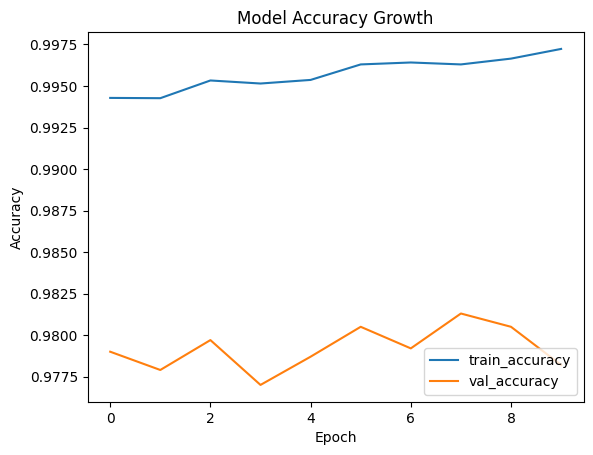

In [7]:
import matplotlib.pyplot as plt

# You must catch the output of the fit function
history = model.fit(X_train, y_train, epochs=10, validation_data=(X_test, y_test))

# Plot Accuracy
plt.plot(history.history['accuracy'], label='train_accuracy')
plt.plot(history.history['val_accuracy'], label = 'val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.title('Model Accuracy Growth')
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 421us/step


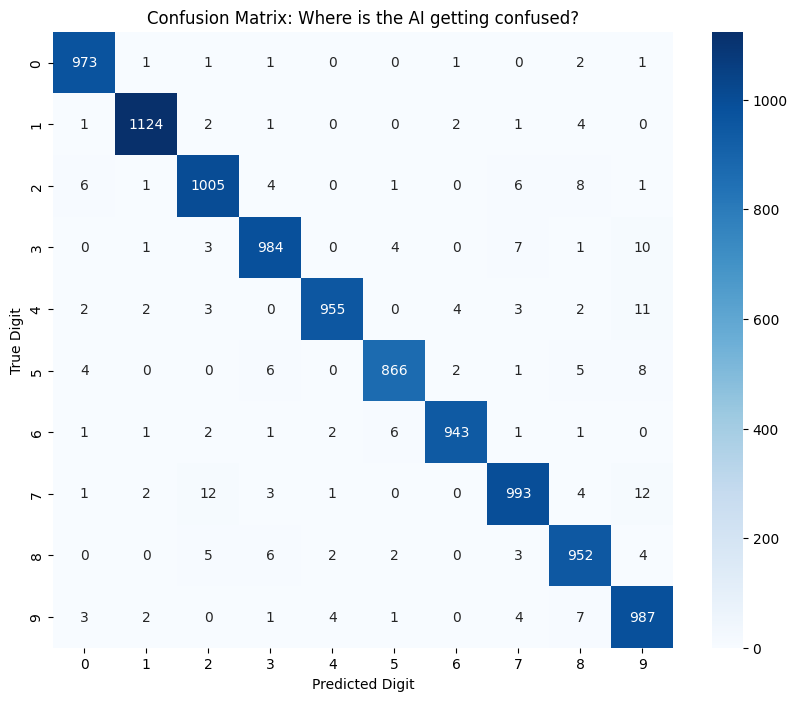

In [17]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import numpy as np

# Get predictions for the whole test set
y_pred = np.argmax(model.predict(X_test), axis=1)

# Create the matrix
cm = confusion_matrix(y_test, y_pred)

# Visualize with a Heatmap
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Digit')
plt.ylabel('True Digit')
plt.title('Confusion Matrix: Where is the AI getting confused?')
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step


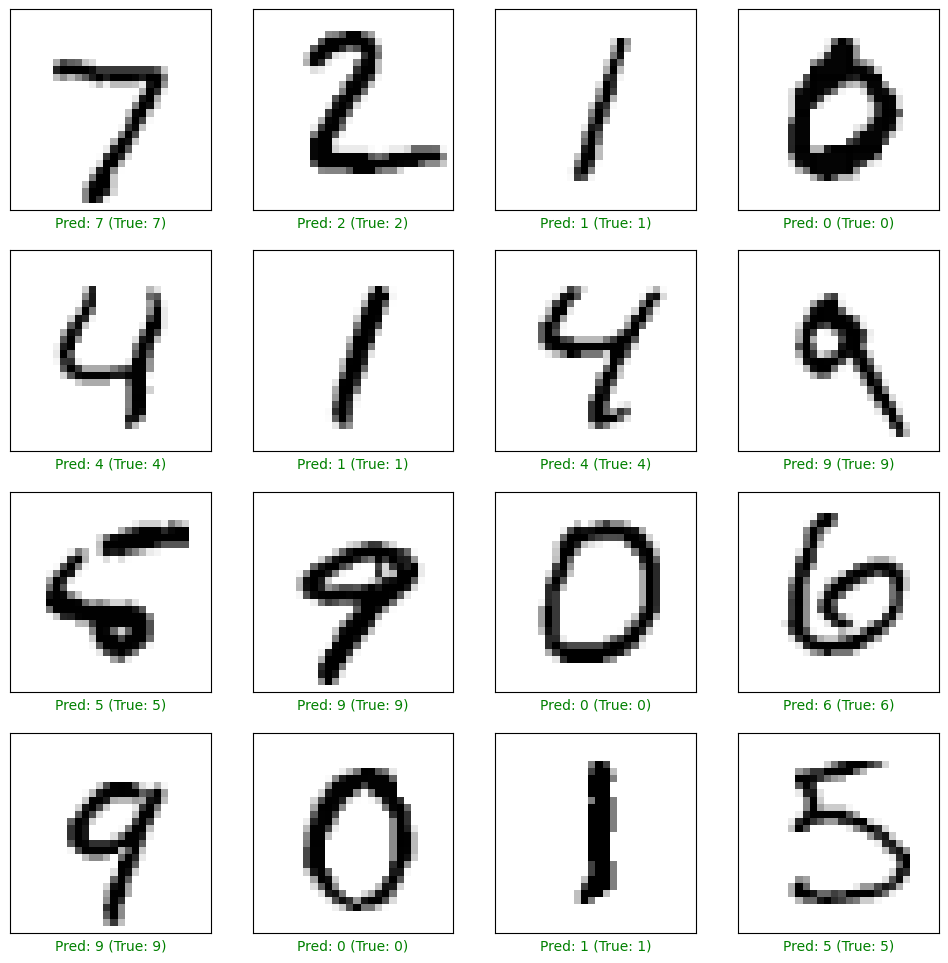

In [18]:
plt.figure(figsize=(12,12))
for i in range(16):
    plt.subplot(4,4,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(X_test[i], cmap=plt.cm.binary)
    
    predicted_label = np.argmax(model.predict(X_test[i:i+1]))
    true_label = y_test[i]
    
    color = 'green' if predicted_label == true_label else 'red'
    plt.xlabel(f"Pred: {predicted_label} (True: {true_label})", color=color)
plt.show()